# Estudio comparativo de algoritmos en un problema de k-armed bandit

*Description:* El experimento compara el rendimiento de algoritmos epsilon-greedy en un problema de k-armed bandit.
Se generan gráficas de recompensas promedio para cada algoritmo.

    Authors: David Fernández Expósito
             Ángel Martínez Sánchez
             Javier Polo Gambín
    Emails: dfernandezexposito@um.es
            angel.martinezs@um.es
            javier.polog@um.es
    Date: 2026/02/14

This software is licensed under the GNU General Public License v3.0 (GPL-3.0),
with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html



## Preparación del entorno


Primero copiamos nuestro repositorio.

In [1]:
!git clone https://github.com/angelms2003/FernandezMartinezPolo-EML-RL.git


Cloning into 'FernandezMartinezPolo-EML-RL'...
remote: Enumerating objects: 152, done.
remote: Counting objects: 100% (152/152), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 152 (delta 85), reused 113 (delta 46), pack-reused 0 (from 0)
Receiving objects: 100% (152/152), 1.29 MiB | 10.29 MiB/s, done.
Resolving deltas: 100% (85/85), done.


In [2]:
!cd FernandezMartinezPolo-EML-RL/

In [3]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/FernandezMartinezPolo-EML-RL/k_brazos/src')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecay, UCB1, UCB2
from arms import ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret


['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/usr/local/lib/python3.12/dist-packages', '/usr/lib/python3/dist-packages', '/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/FernandezMartinezPolo-EML-RL/k_brazos/src']


## Experimento

En este notebook se analiza un problema de bandido multi-brazo de 10 brazos, donde cada brazo sigue una distribución de Bernoulli. Se implementan dos variantes del algoritmo UCB1 y dos variantes del algoritmo UCB2, utilizando distintos valores de los parámetros (c) y (\alpha).

Cada política se evalúa a lo largo de 2000 iteraciones, y todo el experimento se repite 500 veces de forma independiente. En cada iteración se calcula la media de las recompensas obtenidas considerando esas 500 ejecuciones.

La razón por la que se usan 2000 iteraciones, mientras que en los experimentos con los demás algoritmos fueron menos de forma general es que estos algoritmos requieren un horizonte temporal mayor para mostrar su comportamiento asintótico. En particular, el término de exploración depende logarítmicamente del número total de pasos, por lo que con más iteraciones se obtiene una estimación más estable del arrepentimiento y de la convergencia hacia el brazo óptimo.

La comparación entre algoritmos se realiza utilizando varias métricas: recompensa media, proporción media de selecciones óptimas, arrepentimiento acumulado medio, así como la ganancia media y el número medio de selecciones realizadas en cada brazo.


In [33]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar los rechazos promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Asegurar reproducibilidad de resultados.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        sum_current_run_expected_value = np.zeros(len(algorithms)) # Aquí se almacena el valor esperado acumulado para cada algoritmo de esta run. Necesario para calcular el rechazo

        for idx, algo in enumerate(algorithms):
          for step in range(steps):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                # Modificar optimal_selections cuando el brazo elegido se corresponde con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1

                # Si el step actual es 0, el valor esperado acumulado se inicializa con el valor esperado del brazo
                # elegido actualmente. Si no, se suma el valor esperado del brazo actual al valor acumulado
                if step == 0:
                    sum_current_run_expected_value[idx] = bandit.get_expected_value(chosen_arm)
                else:
                    sum_current_run_expected_value[idx] = sum_current_run_expected_value[idx] + bandit.get_expected_value(chosen_arm)

                #regrets[idx, step] = regrets[idx, step-1] + (bandit.get_expected_value(optimal_arm) - reward) if step > 0 else bandit.get_expected_value(optimal_arm) - reward
                regrets[idx, step] += (step+1)*bandit.get_expected_value(optimal_arm) - sum_current_run_expected_value[idx]

    rewards /= runs
    regrets /= runs

    # Calcular el porcentaje de selecciones óptimas
    optimal_selections = optimal_selections*100/runs

    return rewards, regrets, optimal_selections

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución gaussina con desviación 1. Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 3 algoritmos epsilon greedy para valores epsilon: 0.0, 0.01, y 0.1.

In [38]:

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 2000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar.
algorithms = [UCB1(k=k, c=0.1), UCB1(k=k, c=1.0), UCB2(k=k, alpha=0.3), UCB2(k=k, alpha=0.9)]
# Ejecutar el experimento y obtener las recompensas promedio, rechazo acumulado y promedio de las selecciones óptimas
rewards, regrets, optimal_selections = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmBinomial(n=7, p=0.80), ArmBinomial(n=8, p=0.60), ArmBinomial(n=7, p=0.45), ArmBinomial(n=7, p=0.06), ArmBinomial(n=8, p=0.33), ArmBinomial(n=8, p=0.71), ArmBinomial(n=6, p=0.06), ArmBinomial(n=8, p=0.83), ArmBinomial(n=6, p=0.00), ArmBinomial(n=5, p=0.62)
Optimal arm: 8 with expected reward=6.64


## Visualización de los resultados

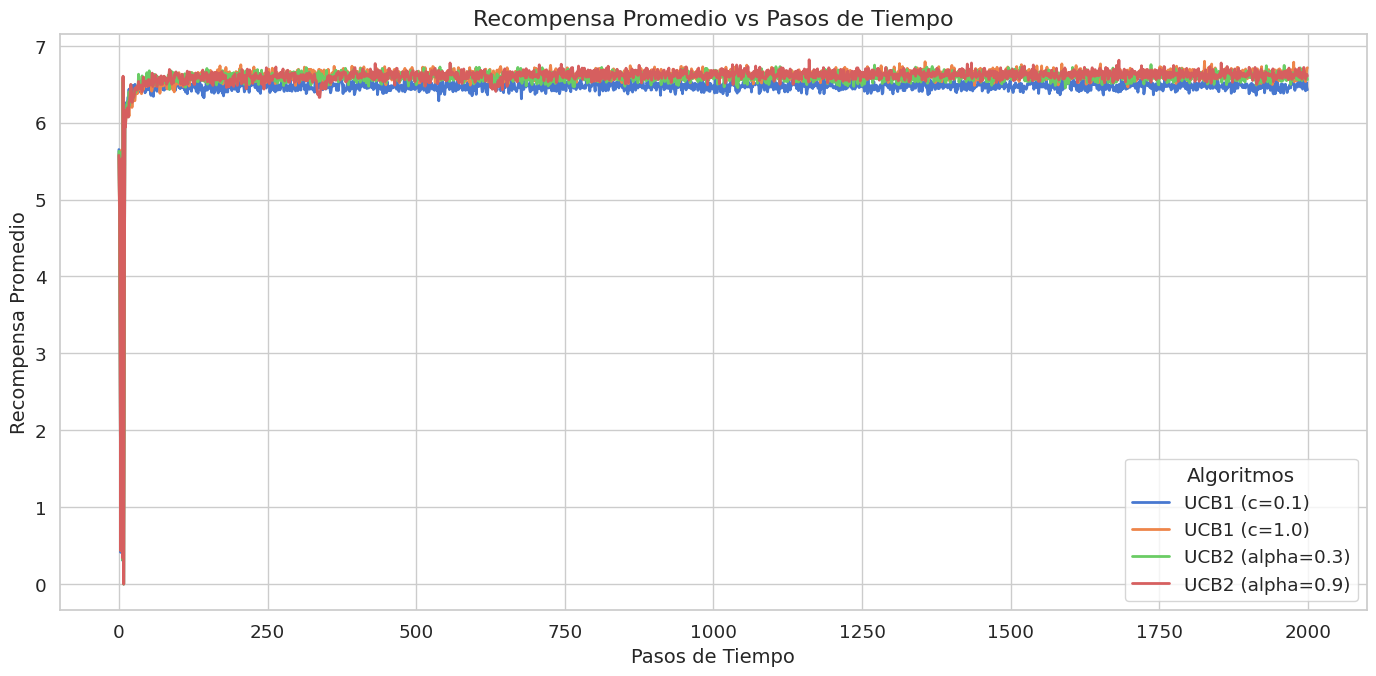

In [39]:

# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)


**ANÁLISIS DETALLADO DE LA IMAGEN**

La imagen muestra un gráfico de líneas titulado **"Recompensa Promedio vs Pasos de Tiempo"**, donde se compara el comportamiento de distintas configuraciones de los algoritmos **UCB1** y **UCB2**. En el eje **x** aparecen los **pasos de tiempo**, mientras que en el eje **y** se representa la **recompensa promedio** obtenida por cada política a lo largo del proceso de aprendizaje.

**1. Interpretación de las líneas del gráfico**

En la gráfica aparecen cuatro curvas, cada una correspondiente a una configuración distinta de los algoritmos:

- **Azul (UCB1 con $c = 0.1$):** Representa una estrategia con exploración baja (explotadora), donde el algoritmo explora alternativas pero prioriza las acciones que ya han demostrado buen rendimiento.  
- **Naranja (UCB1 con $c = 1.0$):** Representa una estrategia más exploradora, ya que un valor alto de $c$ incrementa el peso del término de exploración.  
- **Verde (UCB2 con $\alpha = 0.3$):** Estrategia con exploración moderada dentro del esquema basado en épocas característico de UCB2.  
- **Roja (UCB2 con $\alpha = 0.9$):** Estrategia altamente exploradora, donde se favorece probar brazos menos seleccionados.


**2. Evolución de la recompensa promedio**

De forma general, todos los algoritmos convergen hacia valores altos de recompensa promedio, situándose aproximadamente alrededor de $6.5$. Esto indica que todos consiguen identificar los mejores brazos conforme aumenta el número de pasos.

Además, en este caso no hay muchas diferencias en cuanto a velocidad de convergencia o de fluctuaciones, lo que sí ocurría en otras gráficas de otros experimentos.

**UCB1 ($c = 0.1$) — Línea azul**

Esta configuración parece presentar el crecimiento más rápido, aunque tras los primeros pasos se queda constantemente ligeramente por debajo de las demás. Esto sugiere que la exploración más baja que las otra UCB1 hace que no encuentre el óptimo como seguramente haga la otra, haciendo que su recompensa se quede por debajo.

**UCB1 ($c = 1.0$) — Línea naranja**

Esta curva presenta una fase inicial más inestable, con una velocidad menor de subida inicial. Esto ocurre porque el algoritmo realiza más exploración.

Con el paso del tiempo la recompensa mejora, situándose como una de las mejores. Esto parece indicar, al contrario que con UCB1 con $c = 0.1$, que encuentra el óptimo.

**UCB2 ($\alpha = 0.3$) — Línea verde**

Muestra un crecimiento inicial razonablemente rápido, similar al de la línea naranja. Sin embargo, parece quedarse ligeramente por detrás de esta, aunque ligeramente por encima de la azul.

**UCB2 ($\alpha = 0.9$) — Línea roja**

Es la curva más inestable al inicio. Se observan caídas muy pronunciadas en los primeros pasos, lo que indica exploración agresiva y selección frecuente de brazos con baja recompensa.

Conforme aumentan los pasos de tiempo, la curva se estabiliza y alcanza niveles similares al resto de algoritmos, aunque mantiene algo más de variabilidad. Finalmente, parece quedarse a la par que a línea naranja, obteniendo de los mejores resultados finales.

**3. Conclusiones**

El gráfico de Recompensa Promedio revela que todos los algoritmos muestran un desempeño sumamente parejo, logrando identificar el brazo óptimo de manera casi inmediata y estabilizándose en una recompensa superior a 6 tras apenas unos pocos pasos de tiempo. La única desviación notable ocurre en la línea roja (UCB2 con $\alpha=0.9$), la cual experimenta una caída abrupta y puntual en el tramo inicial, lo que sugiere que su configuración más agresiva lo llevó a explorar una acción con una recompensa muy baja antes de converger. A pesar de este bache temprano, el resto de la trayectoria para todos los modelos es prácticamente idéntica, manteniendo un nivel de éxito sostenido y uniforme durante todo el experimento, aunque sí que parece que las estrategias exploradoras obtienen un ligero superior resultado.








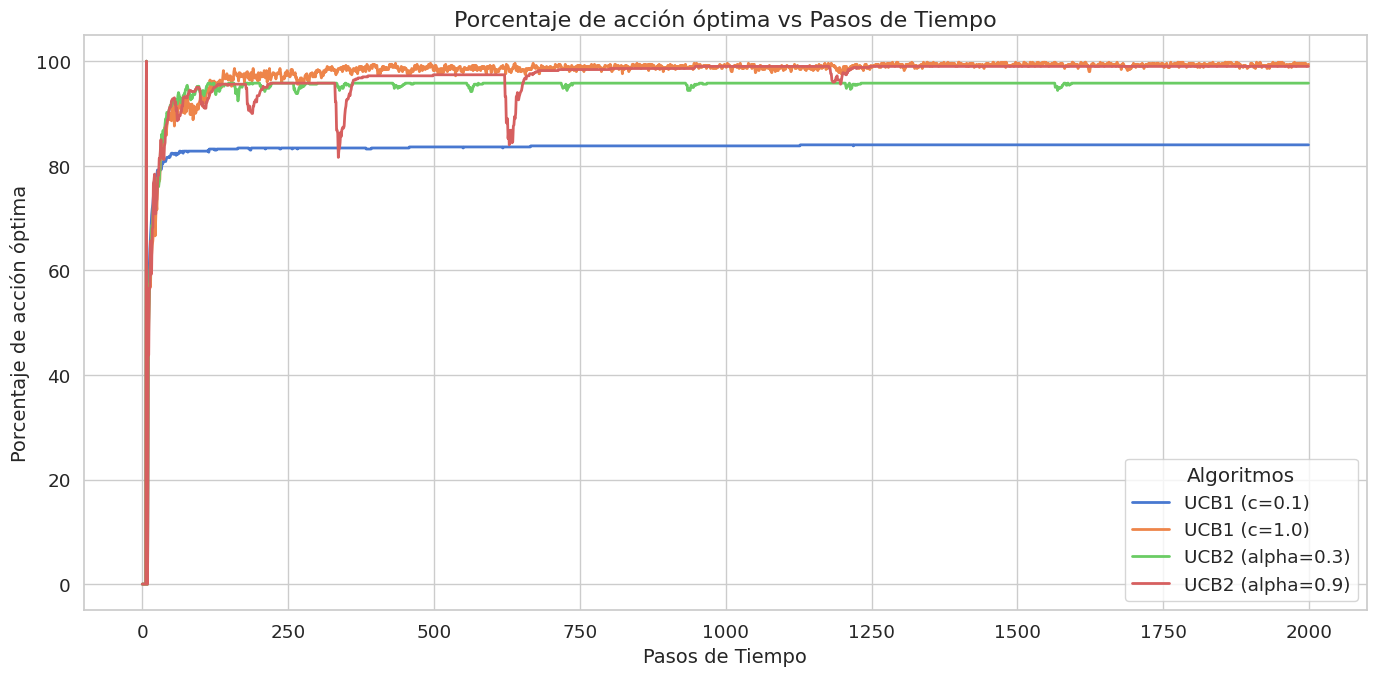

In [40]:
plot_optimal_selections(steps, optimal_selections, algorithms)

**ANÁLISIS DETALLADO DE LA IMAGEN**

La imagen muestra un gráfico de líneas titulado **"Porcentaje de acción óptima vs Pasos de Tiempo"**, donde se compara el rendimiento de distintas configuraciones de los algoritmos **UCB1** y **UCB2**. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **porcentaje de veces que se selecciona la acción óptima**.

**1. Interpretación de las líneas del gráfico**

En la gráfica aparecen cuatro curvas, cada una asociada a una configuración distinta:

- **Azul (UCB1 con $c = 0.1$):** Representa una estrategia con exploración baja (explotadora), donde el algoritmo explora alternativas pero prioriza las acciones que ya han demostrado buen rendimiento.  
- **Naranja (UCB1 con $c = 1.0$):** Representa una estrategia más exploradora, ya que un valor alto de $c$ incrementa el peso del término de exploración.  
- **Verde (UCB2 con $\alpha = 0.3$):** Estrategia con exploración moderada dentro del esquema basado en épocas característico de UCB2.  
- **Roja (UCB2 con $\alpha = 0.9$):** Estrategia altamente exploradora, donde se favorece probar brazos menos seleccionados.


**2. Evolución del porcentaje de acción óptima**

Todas las configuraciones muestran un aumento progresivo en el porcentaje de selección de la acción óptima, lo que indica aprendizaje efectivo del mejor brazo.

Sin embargo, existen diferencias claras en:

- Velocidad con la que se identifica la acción óptima  
- Estabilidad de la selección  
- Oscilaciones provocadas por la exploración continua  

**UCB1 ($c = 0.1$) — Línea azul**

Esta configuración muestra el crecimiento más rápido hacia valores altos, aunque se estanca en valores claramente inferiores al resto. Tras una fase inicial muy corta, el algoritmo alcanza aproximadamente un $85\%$ de selección de la acción óptima y se mantiene muy estable hasta el final.

**UCB1 ($c = 1.0$) — Línea naranja**

Es el modelo que mejor rendimiento ofrece. Muestra un gran crecimiento inicial y consigue alcanzar casi el 100% de selecciones óptimas antes del paso 500.

**UCB2 ($\alpha = 0.3$) — Línea verde**

Muestra un crecimiento muy parecido al de la línea azul, aunque en este caso la línea se estanca en valores superiores, cercanos al 95%.

Presenta oscilaciones moderadas, probablemente asociadas a los cambios entre épocas del algoritmo. Sin embargo, mantiene un buen rendimiento general.

**UCB2 ($\alpha = 0.9$) — Línea roja**

Es la configuración más inestable. Presenta grandes oscilaciones a lo largo de todo el experimento, con picos cercanos al $100\%$ seguidos de caídas pronunciadas.

Esto indica una exploración muy agresiva, que provoca que el algoritmo abandone temporalmente el mejor brazo para explorar otros, reduciendo el porcentaje de selección óptima en ciertos intervalos.

**3. Conclusiones**

El gráfico refleja claramente cómo el nivel de exploración influye en la capacidad de seleccionar la acción óptima. En este caso, parece que los enfoques más exploradores obtienen un mejor resultado, obviando claro está las diferencias entre UCB1 y UCB2. En el segundo, su naturaleza hace que sus gráficas muestren ciertas ondulaciones, sobre todo con valores de alpha más altos.

En este experimento, la configuración que ofrece el comportamiento más sólido es UCB1 con un nivel alto de exploración.







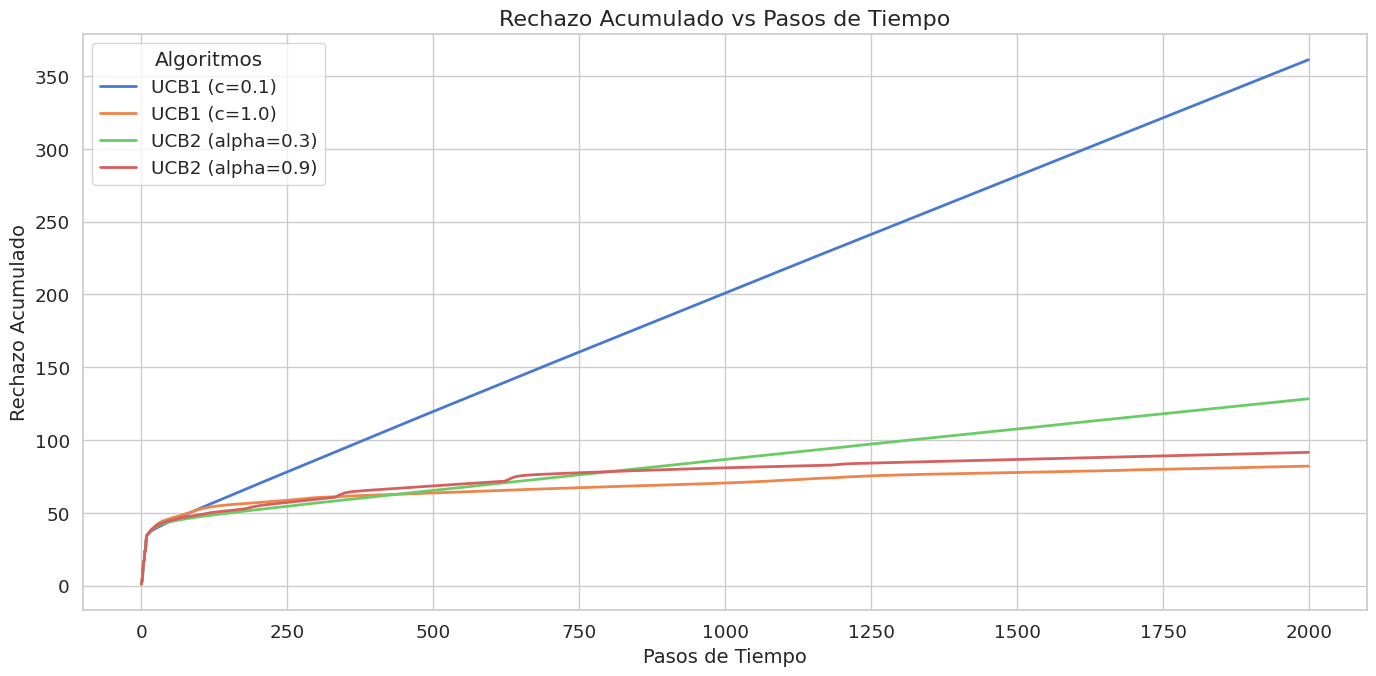

In [41]:
plot_regret(steps, regrets, algorithms)

**ANÁLISIS DETALLADO DE LA IMAGEN**

La imagen muestra un gráfico de líneas titulado **"Rechazo Acumulado vs Pasos de Tiempo"**, donde se compara el rendimiento de distintas configuraciones de los algoritmos **UCB1** y **UCB2**. En el eje **x** se representan los **pasos de tiempo**, mientras que en el eje **y** se muestra el **rechazo acumulado**, que mide la pérdida total respecto a la recompensa que se habría obtenido seleccionando siempre la acción óptima.

### **1. Interpretación de las líneas del gráfico**

En la gráfica aparecen cuatro curvas, cada una correspondiente a una configuración distinta:

- **Azul (UCB1 con $c = 0.1$):** Representa una estrategia con exploración baja (explotadora), donde el algoritmo explora alternativas pero prioriza las acciones que ya han demostrado buen rendimiento.  
- **Naranja (UCB1 con $c = 1.0$):** Representa una estrategia más exploradora, ya que un valor alto de $c$ incrementa el peso del término de exploración.  
- **Verde (UCB2 con $\alpha = 0.3$):** Estrategia con exploración moderada dentro del esquema basado en épocas característico de UCB2.  
- **Roja (UCB2 con $\alpha = 0.9$):** Estrategia altamente exploradora, donde se favorece probar brazos menos seleccionados.

### **2. Evolución global del rechazo acumulado**

El rechazo acumulado crece con el número de pasos para todos los algoritmos, lo cual es esperable, ya que incluso los mejores algoritmos necesitan explorar en ciertas fases del aprendizaje.

Sin embargo, las diferencias entre algoritmos son claras:

#### **UCB1 ($c = 0.1$) — Línea azul**
Es la línea que peor resultado obtiene. Siguiendo con la línea vista en la gráfica anterior, su rechazo crece constantemente debido a que mantiene un porcentaje constante de elecciones no óptimas.

#### **UCB1 ($c = 1.0$) — Línea naranja**

Es la curva con mejor comportamiento. El rechazo acumulado crece de forma casi constante durante todo el experimento, pero a un ritmo mucho menor que en el caso de la línea azul. Esto es coherente con lo visto en la gráfica anterior, ya que vimos que este enfoque elegía casi siempre la opción óptima.

#### **UCB2 ($\alpha = 0.3$) — Línea verde**

Obtiene peor resultado que las líneas naranja y rojo pero es claramente mejor que la azul. De nuevo, crece a un ritmo constante debido al porcentaje de veces que no elige la opción óptima. Siguiendo la tendencia vista en la gráfica anterior, este enfoque se queda un poco por detrás de la línea naranja y roja.

#### **UCB2 ($\alpha = 0.9$) — Línea roja**

Es la segunda mejor línea. Crece de forma similar a la naranja, aunque está un poco por encima. Esto es coherente, de nuevo, con lo visto en la gráfica anterior.

### **3. Conclusiones**

El gráfico muestra claramente el impacto del nivel de exploración sobre el rechazo acumulado. Las estrategias con exploración alta obtienen en este caso mejores resultados, minimizando la pérdida acumulada. Esto se deberá a que las opciones menos exploradoras no consiguen encontrar la opción óptima suficientes veces.

En este experimento, la configuración con mejor rendimiento global es UCB1 con exploración alta, ya que consigue mantener el rechazo acumulado en valores bajos durante todo el proceso.

## **Conclusiones**

En este estudio hemos analizado un **problema de toma de decisiones secuenciales** modelado mediante un **Multi-Armed Bandit (MAB)**, un marco fundamental dentro del aprendizaje por refuerzo y la teoría de decisión. En este contexto, un agente debe aprender qué acción maximiza la recompensa únicamente a partir de la experiencia obtenida durante la interacción con el entorno.

En este experimento se han evaluado distintas configuraciones de los algoritmos **UCB1** y **UCB2** con brazos binomiales, comparando su comportamiento mediante varias métricas: recompensa promedio, porcentaje de selección de acción óptima y rechazo acumulado.

### **1. Exploración vs Explotación**

En este caso, los mejores resultados los han obtenido los enfoques más exploradores, mientras que los enfoques menos exploradores han tenido problemas para encontrar el brazo óptimo y por tanto no han podido obtener mejores resultados.

### **2. Análisis conjunto de las métricas**

#### **Recompensa Promedio**

Los algoritmos con exploración más alta alcanzan rápidamente valores cercanos al óptimo y se mantienen estables. Aunque es cierto que con UCB2 debido a su naturaleza existen oscilaciones.

#### **Porcentaje de Acción Óptima**

Se observa que:

- Las estrategias con exploración bajas alcanzan rápidamente valores cercanos al $85\%$, pero se quedan ahi, por debajo de las demás.
- Las estrategias muy exploradoras presentan una convergencia a porcentaje mayores, cercanos al $95\%$


#### **Rechazo Acumulado**

Esta métrica refuerza las conclusiones anteriores. La exploración baja muestra un crecimiento más rápido del rechazo acumulado, mientras la exploración alta muestra un rcecimiento continuo pero más lento.

### **3. Velocidad de Convergencia**

Los resultados obtenidos son bastante similares en este sentido, todos los enfoques convergen rápidamente. Aunque es cierto que con UCB2 existen oscilaciones provocadas por su naturaleza y uso de épocas.

### **4. Interpretación práctica**

En problemas reales de toma de decisiones un equilibrio adecuado entre exploración y explotación es fundamental para maximizar el rendimiento a largo plazo.

Los resultados sugieren que una estrategia de exploración permite:

- Aprender rápido cuál es la mejor opción.
- Mantener resultados estables.
- Minimizar pérdidas acumuladas.